# 10 — TBM-X Stability & Control

Longitudinal stability, static margin, trim ve elevator control authority için kavramsal ilk model. Varsayımlar açıkça belirtilir; bu bir sertifikasyon analizi değildir.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
OUT=Path('outputs/stability_control'); OUT.mkdir(parents=True,exist_ok=True)
# Preliminary assumptions
x_cg=0.25; x_ac=0.25; CLalpha=4.8; tail_volume=0.85; eta=0.90; depsilon=0.35; tail_CLalpha=3.5
x_np=x_ac+(eta*tail_volume*tail_CLalpha*(1-depsilon)/CLalpha)
static_margin=x_np-x_cg
print(f'Neutral point = {x_np:.3f} cbar')
print(f'Static margin = {static_margin*100:.1f}%')

Neutral point = 0.613 cbar
Static margin = 36.3%


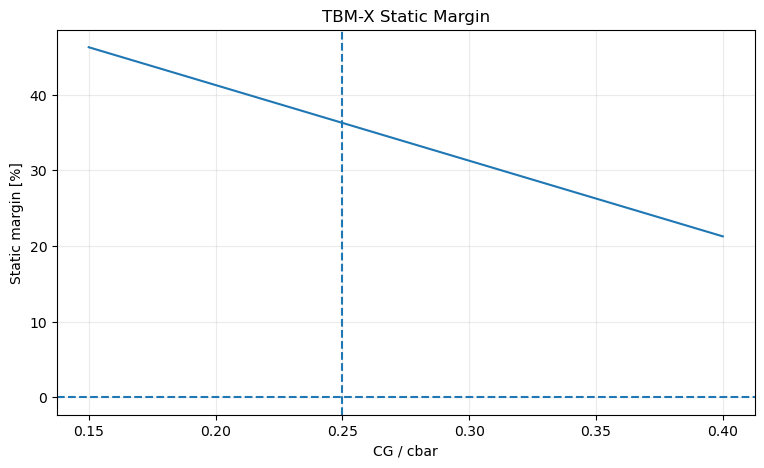

In [2]:
cg=np.linspace(.15,.40,200); sm=(x_np-cg)*100
plt.figure(figsize=(9,5)); plt.plot(cg,sm); plt.axhline(0,ls='--'); plt.axvline(x_cg,ls='--'); plt.xlabel('CG / cbar'); plt.ylabel('Static margin [%]'); plt.title('TBM-X Static Margin'); plt.grid(alpha=.25); plt.show()

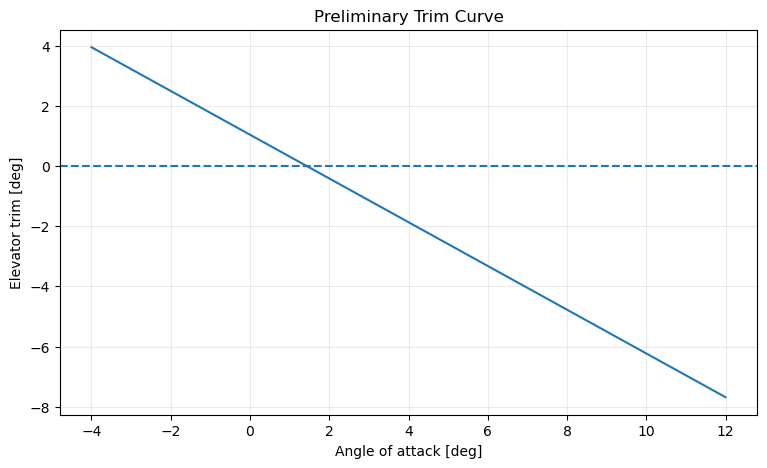

,parameter,value
0,Neutral point [cbar],0.612578
1,CG [cbar],0.250000
2,Static margin [%],36.257813
3,Max elevator [deg],7.685531


In [3]:
Cm0=.02; Cm_alpha=-.80; Cm_de=-1.10
alpha=np.linspace(-4,12,200); Cm=Cm0+Cm_alpha*np.deg2rad(alpha); de=-Cm/Cm_de
plt.figure(figsize=(9,5)); plt.plot(alpha,np.rad2deg(de)); plt.axhline(0,ls='--'); plt.xlabel('Angle of attack [deg]'); plt.ylabel('Elevator trim [deg]'); plt.title('Preliminary Trim Curve'); plt.grid(alpha=.25); plt.show()
summary=pd.DataFrame({'parameter':['Neutral point [cbar]','CG [cbar]','Static margin [%]','Max elevator [deg]'],'value':[x_np,x_cg,static_margin*100,np.max(np.abs(np.rad2deg(de)))]}); summary.to_csv(OUT/'stability_control_summary.csv',index=False); summary